importing libraries and loading data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
laptop_prices_df = pd.read_csv('laptop_price - dataset.csv', index_col ='Company', header = 0)
laptop_prices_df.head(8)

,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro)
Company,,,,,,,,,,,,,,
Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69
Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94
HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00
Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45
Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60
Acer,Aspire 3,Notebook,15.6,1366x768,AMD,A9-Series 9420,3.0,4,500GB HDD,AMD,Radeon R5,Windows 10,2.10,400.00
Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.2,16,256GB Flash Storage,Intel,Iris Pro Graphics,Mac OS X,2.04,2139.97
Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,256GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,1158.70


extracting the price column from the dataset
plotting the distribution of the laptop prices in euro

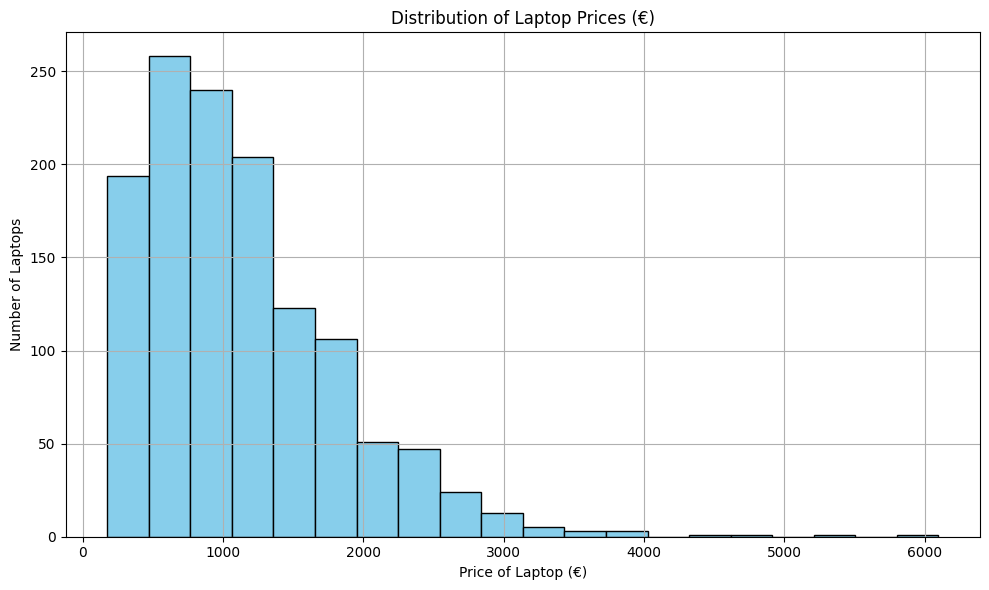

In [11]:
prices = laptop_prices_df['Price (Euro)']
plt.figure(figsize=(10, 6))
plt.hist(prices, bins = 20, color = 'skyblue', edgecolor = 'black')
plt.grid(True)
plt.xlabel('Price of Laptop (€)')
plt.ylabel('Number of Laptops')
plt.title('Distribution of Laptop Prices (€)')
plt.tight_layout()
plt.show()

computing average laptop price per company

In [12]:
company_price_avg = laptop_prices_df.groupby('Company').agg({'Price (Euro)': 'mean'})
print("\n---Average Laptop Price per Company---")
company_price_avg


---Average Laptop Price per Company---


,Price (Euro)
Company,
Acer,633.464455
Apple,1564.198571
Asus,1123.829737
Chuwi,314.296667
Dell,1199.225120
Fujitsu,729.000000
Google,1677.666667
HP,1080.314664
Huawei,1424.000000


company with the most expensive laptop on average

In [ ]:
company_avg_sorted = company_price_avg.sort_values(by = 'Price (Euro)', ascending =False)
print("The company with the most expensive laptops on average: ", company_avg_sorted.index[0])

The commpany with the most expensive laptops on average:  Razer


check for similar operating systems and unify them under consistent names

In [14]:
os_unique = laptop_prices_df["OpSys"].unique().copy()
print("Original OS types: ", os_unique)
os_mapping = {
    'Mac OS X': 'macOS', 
    'Windows 10 S': 'Windows 10'
}
laptop_prices_df["OpSys"].replace(os_mapping, inplace=True)
clean_os_unique = laptop_prices_df["OpSys"].unique()
print("Clean OS types: ", clean_os_unique)

Original OS types:  ['macOS' 'No OS' 'Windows 10' 'Linux' 'Android' 'Chrome OS' 'Windows 7']
Clean OS types:  ['macOS' 'No OS' 'Windows 10' 'Linux' 'Android' 'Chrome OS' 'Windows 7']


plot price distribution for each unique operating systems

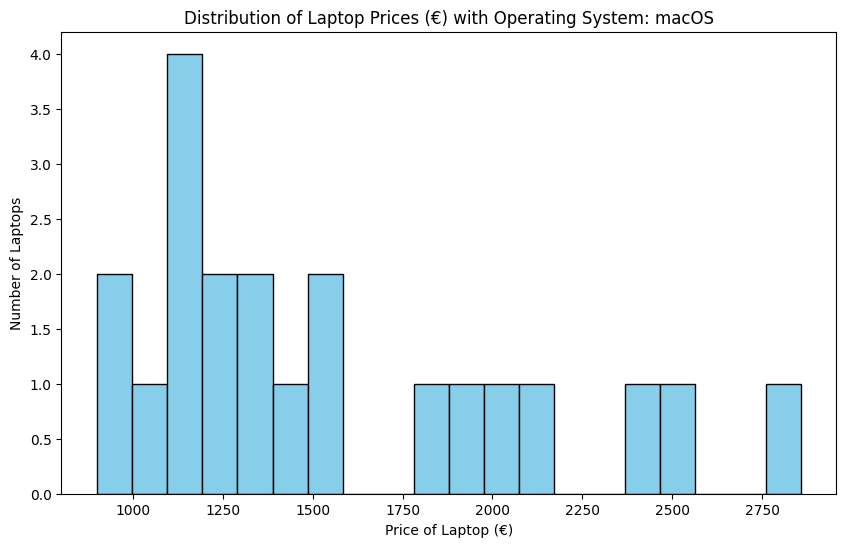

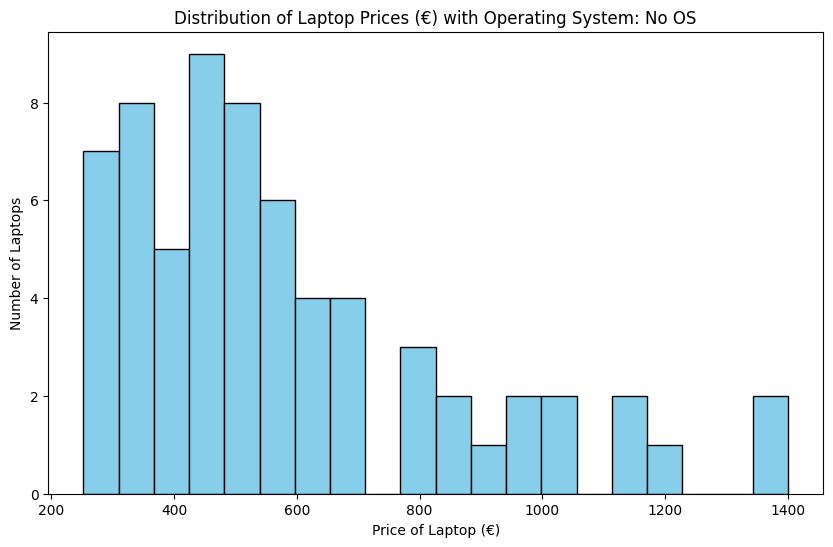

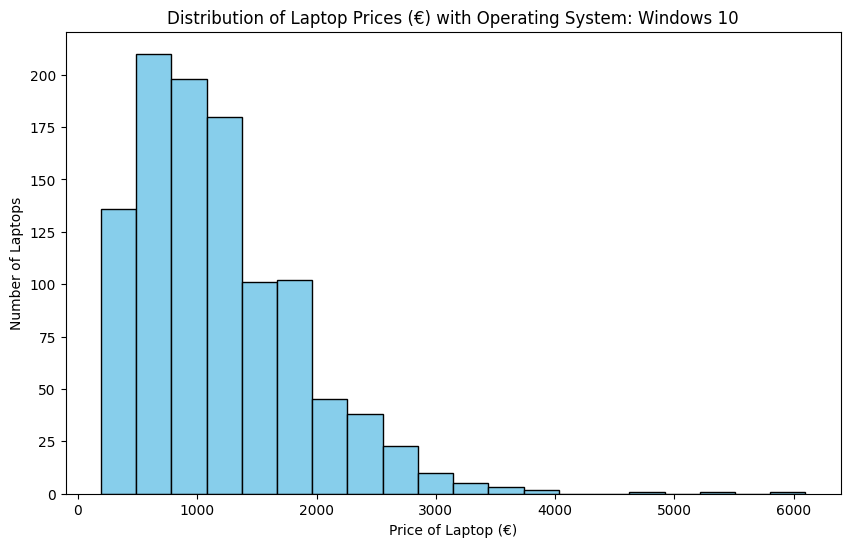

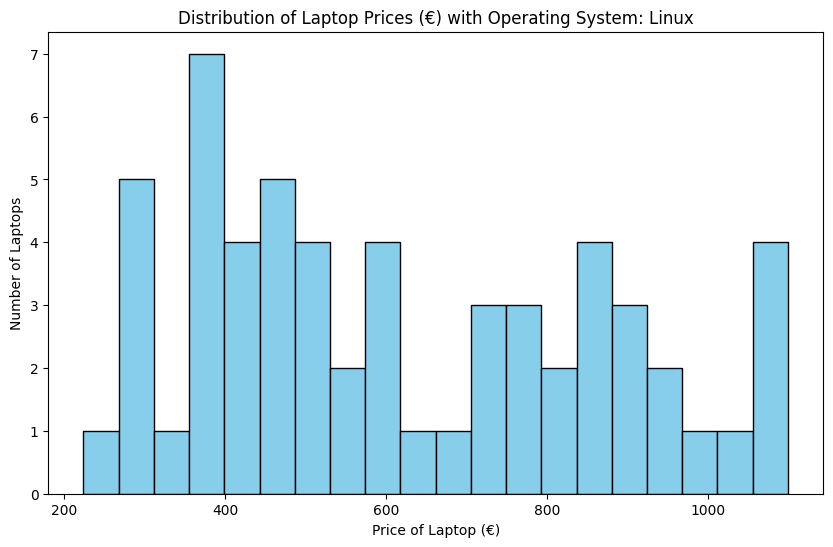

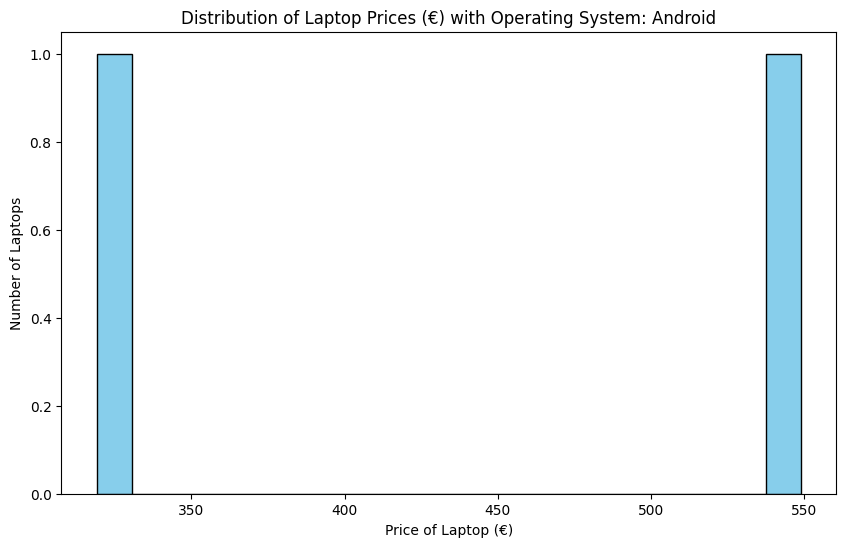

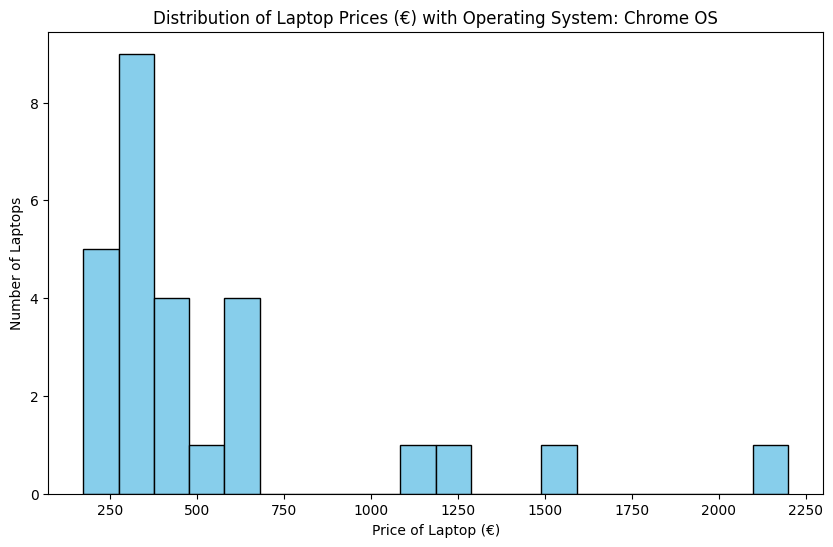

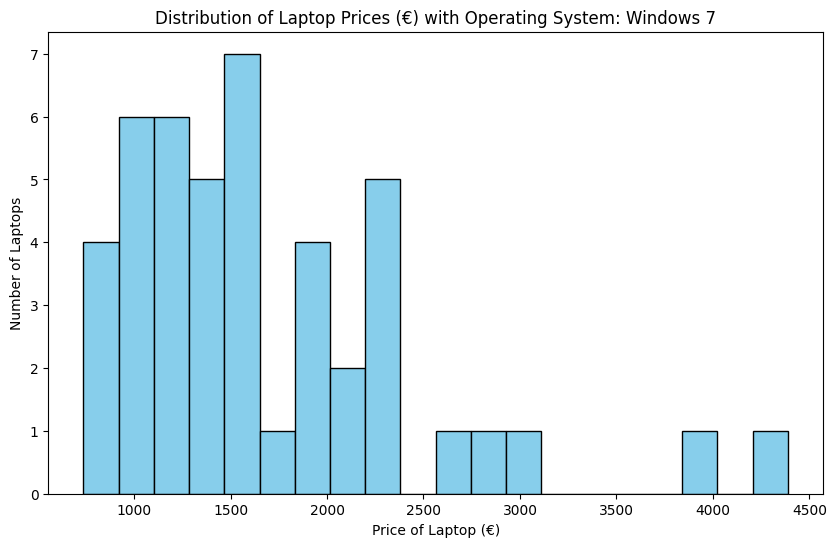

In [ ]:
for os in clean_os_unique:
    os_df = laptop_prices_df[laptop_prices_df['OpSys'] == os]
    plt.figure(figsize=(10, 6))
    plt.hist(os_df['Price (Euro)'], bins = 20, color = 'skyblue', edgecolor = 'black')
    plt.grid(True)
    plt.xlabel('Price of Laptop (€)')
    plt.ylabel('Number of Laptops')
    plt.title(f'Distribution of Laptop Prices (€) with Operating System: {os}')
    plt.tight_layout()
    plt.show()

detecting outliers in the dataset - using the IQR method: compute 25th percentile (lower) and 75th (upper), and subtract them to obtain the IQR. calculate the bounds using conventional method: 1.5 * IQR. any laptop with a price falling outside these bounds will be considered a price outlier.
at the end we create a new clean df without outliers.

In [16]:
#detect outliers using IQR
lower_percentile = laptop_prices_df['Price (Euro)'].quantile(0.25)
upper_percentile = laptop_prices_df['Price (Euro)'].quantile(0.75)
IQR = upper_percentile - lower_percentile

lower_bound = lower_percentile - 1.5 * IQR
upper_bound = upper_percentile + 1.5 * IQR

#remove outliers
clean_df = laptop_prices_df[
    (laptop_prices_df['Price (Euro)'] >= lower_bound) &
    (laptop_prices_df['Price (Euro)'] <= upper_bound)
]

Plot: Correlation between RAM and laptop price (excluding outliers)

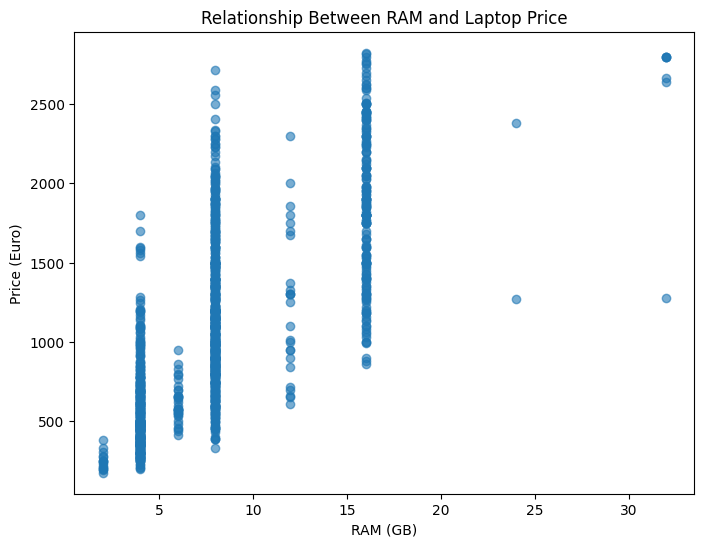

In [ ]:
#plot the correlation without outliers
plt.figure(figsize=(8,6))
plt.scatter(clean_df['RAM (GB)'],
            clean_df['Price (Euro)'],
            alpha=0.6)
plt.xlabel('RAM (GB)')
plt.ylabel('Price (Euro)')
plt.title('Relationship Between RAM and Laptop Price')
plt.tight_layout
plt.show()


The scatter plot indicates a moderate positive correlation between RAM size and laptop price - Laptops with higher RAM generally tend to be more expensive. As RAM increases, the average price increases accordingly. However, there is a significant price variation for mid-range sized RAMs, showing that RAM alone does not determine the laptop price. Other factors are important too, such as storage type and brand.  

in order to separate the different types of storage types we first need to separate memories with multiple parts, like 128GB SSD + 128GB HDD. the result is in a new column called - memory_split

In [18]:
laptop_prices_df['Memory_split'] = laptop_prices_df['Memory'].str.split(r'\s*\+\s*')


creating a specific function to handle all types of memory (after the split): ['128GB SSD'], ['128GB Flash Storage'], ['128GB SSD, 1TB HDD']

In [19]:
def extract_storage(memory_list):
    storage_types = []
    for part in memory_list:
        #split at the first space
        split_part = part.split(' ', 1)
        #take everything after the first space (the storage type)
        storage_type = split_part[1]
        #add it to the storage types list
        storage_types.append(storage_type)

    #join multiple storage types with + if there are more than one
    return ' + '.join(storage_types)

laptop_prices_df['Storage type'] = laptop_prices_df['Memory_split'].apply(extract_storage)